# Module 4 — Isolation Forest on NASA MSL

## What Isolation Forest Does

Isolation Forest anomaly-scores each sample by how quickly it gets isolated when the feature space is recursively partitioned with random splits. Anomalies are isolated in fewer splits (shorter average path length) because they tend to occupy sparse, low-density regions.

**Why it suits MSL:**
- No distributional assumptions — works equally well on continuous and binary features
- Handles the 55-feature space (feature 0 continuous + 54 binary telecommands) without modification or scaling
- Can detect **multivariate** anomalies: an unusual combination of `(feature_0_value, command_state)` at a single timestep, even if each is within normal range individually

**Fundamental limitation:**
Isolation Forest is **pointwise** — it scores each timestep independently with no memory of preceding values. It cannot detect **collective anomalies** (regime shifts where each individual timestep looks normal but the sustained pattern is wrong). This is the structural gap that LSTM-AE is designed to close.

## Position in the Benchmark

| Model | Features | Temporal | What it can detect |
|-------|----------|----------|--------------------|
| **Isolation Forest** (this notebook) | all 55 | No | Point + multivariate contextual |
| Vanilla AE | all 55 | No | Point + multivariate contextual |
| LSTM-AE | all 55 | Yes | Point + contextual + collective |

IF vs Vanilla AE isolates whether *learned reconstruction* helps over random partitioning.  
AE vs LSTM-AE isolates the contribution of temporal context.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score

DATA_ROOT    = '../data/NASA/data/data'
TRAIN_DIR    = f'{DATA_ROOT}/train'
TEST_DIR     = f'{DATA_ROOT}/test'
LABELS_CSV   = '../data/NASA/labeled_anomalies.csv'
N_ESTIMATORS = 200
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [4]:
# Load and parse labels
df_labels = pd.read_csv(LABELS_CSV)
df_labels['anomaly_sequences'] = df_labels['anomaly_sequences'].apply(ast.literal_eval)

def parse_class(s):
    s = s.strip().lstrip('[').rstrip(']')
    return [x.strip() for x in s.split(',')]

df_labels['class_list'] = df_labels['class'].apply(parse_class)

def type_summary(types):
    unique = set(types)
    if unique == {'point'}:       return 'point'
    if unique == {'contextual'}:  return 'contextual'
    return 'mixed'

df_labels['anomaly_type'] = df_labels['class_list'].apply(type_summary)

msl = df_labels[df_labels['spacecraft'] == 'MSL'].copy().reset_index(drop=True)

# Build per-channel data dict
channels = {}
for _, row in msl.iterrows():
    chan_id    = row['chan_id']
    train_arr = np.load(f'{TRAIN_DIR}/{chan_id}.npy').astype(np.float32)
    test_arr  = np.load(f'{TEST_DIR}/{chan_id}.npy').astype(np.float32)

    y_true = np.zeros(len(test_arr), dtype=int)
    for start, end in row['anomaly_sequences']:
        y_true[start:end + 1] = 1

    anomaly_pct = 100 * y_true.sum() / len(y_true)

    channels[chan_id] = {
        'train':        train_arr,
        'test':         test_arr,
        'y_true':       y_true,
        'anomaly_type': row['anomaly_type'],
        'anomaly_pct':  anomaly_pct,
        'sequences':    row['anomaly_sequences'],
        'class_list':   row['class_list'],
    }

total_train = sum(v['train'].shape[0] for v in channels.values())
total_test  = sum(v['test'].shape[0]  for v in channels.values())
type_counts = {t: sum(1 for v in channels.values() if v['anomaly_type'] == t)
               for t in ['point', 'contextual', 'mixed']}

print(f'Loaded {len(channels)} MSL channels')
print(f'Total train timesteps: {total_train:,}')
print(f'Total test  timesteps: {total_test:,}')
print(f'Channel types: {type_counts}')

Loaded 27 MSL channels
Total train timesteps: 58,317
Total test  timesteps: 73,729
Channel types: {'point': 14, 'contextual': 11, 'mixed': 2}


## Feature & Scaling Rationale

**All 55 features, no StandardScaler.**

In the SWaT experiments we dropped binary actuator features because the continuous sensors already captured the relevant variance. MSL is the opposite: there is only *one* continuous sensor (feature 0) and 54 binary telecommand features that encode the causal context.

Including the binary features allows Isolation Forest to detect **multivariate contextual anomalies**: a telemetry reading that is unusual *given which commands are active*, even if the reading looks normal in isolation. This is the best-case scenario for a non-temporal method on the contextual anomalies.

No scaling is needed — tree-based splits operate on rank order, not magnitude. Binary features (0.0/1.0) are valid split points.

In [5]:
# Fit one IF per channel, using oracle contamination (true anomaly rate)
# This isolates detection capability from threshold selection
results = []

for chan_id, data in sorted(channels.items()):
    # Oracle contamination: clip to valid sklearn range
    contamination = max(0.001, min(0.499, data['anomaly_pct'] / 100))

    clf = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=contamination,
        random_state=RANDOM_STATE
    )
    clf.fit(data['train'])

    scores = -clf.score_samples(data['test'])           # higher = more anomalous
    preds  = (clf.predict(data['test']) == -1).astype(int)

    # Threshold used by IF at this contamination level
    threshold = -clf.offset_

    results.append({
        'chan_id':      chan_id,
        'type':        data['anomaly_type'],
        'anomaly_pct': data['anomaly_pct'],
        'f1':          f1_score(data['y_true'], preds, zero_division=0),
        'precision':   precision_score(data['y_true'], preds, zero_division=0),
        'recall':      recall_score(data['y_true'], preds, zero_division=0),
        'scores':      scores,
        'preds':       preds,
        'threshold':   threshold,
    })

print(f'Fitted {len(results)} models')

Fitted 27 models


In [6]:
# Per-channel results table
results_df = pd.DataFrame([
    {'Channel': r['chan_id'], 'Type': r['type'], 'Anomaly %': f"{r['anomaly_pct']:.1f}%",
     'F1': round(r['f1'], 4), 'Precision': round(r['precision'], 4), 'Recall': round(r['recall'], 4)}
    for r in results
]).sort_values('F1', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))
print(f'\nMean F1 (all channels): {results_df["F1"].mean():.4f}')

Channel       Type Anomaly %     F1  Precision  Recall
    M-2 contextual     50.1% 0.7396     0.6315  0.8922
   D-15      point     29.7% 0.6463     0.5311  0.8253
    M-1 contextual     50.1% 0.6407     0.5035  0.8808
    M-7      point      4.7% 0.4636     0.4286  0.5050
   D-16 contextual     29.7% 0.2980     0.2936  0.3026
    T-9      point     10.2% 0.2831     0.2897  0.2768
    F-8 contextual     21.6% 0.2644     0.2496  0.2812
    M-5 contextual     13.1% 0.2312     0.2444  0.2193
    M-4 contextual     12.3% 0.1696     0.1680  0.1713
   T-13 contextual     10.4% 0.1569     0.0980  0.3929
    M-3 contextual     11.8% 0.1365     0.1336  0.1394
    T-8 contextual      6.7% 0.1115     0.0837  0.1667
    C-1      mixed     13.8% 0.1045     0.1145  0.0962
    F-4      point      2.1% 0.0904     0.0755  0.1127
    M-6      point      8.8% 0.0848     0.0773  0.0939
    C-2      mixed      6.7% 0.0759     0.0900  0.0657
    F-5      point      3.9% 0.0671     0.0680  0.0662
   T-12 co

In [7]:
# Aggregate metrics by anomaly type + micro-averaged F1
print('=== Per-Type Metrics ===')
for atype in ['point', 'contextual', 'mixed']:
    subset = [r for r in results if r['type'] == atype]
    if not subset:
        continue
    f1s   = [r['f1']        for r in subset]
    precs = [r['precision'] for r in subset]
    recs  = [r['recall']    for r in subset]
    print(f"{atype:12s}  n={len(subset):2d}  "
          f"mean F1={np.mean(f1s):.4f}  "
          f"mean Prec={np.mean(precs):.4f}  "
          f"mean Rec={np.mean(recs):.4f}")

# Micro-averaged F1: concatenate all predictions
all_true = np.concatenate([channels[r['chan_id']]['y_true'] for r in results])
all_pred = np.concatenate([r['preds'] for r in results])

micro_f1   = f1_score(all_true, all_pred, zero_division=0)
micro_prec = precision_score(all_true, all_pred, zero_division=0)
micro_rec  = recall_score(all_true, all_pred, zero_division=0)

print(f'\n=== Micro-Averaged (all 27 channels concatenated) ===')
print(f'F1={micro_f1:.4f}  Precision={micro_prec:.4f}  Recall={micro_rec:.4f}')

=== Per-Type Metrics ===
point         n=14  mean F1=0.1309  mean Prec=0.1210  mean Rec=0.1500
contextual    n=11  mean F1=0.2580  mean Prec=0.2270  mean Rec=0.3213
mixed         n= 2  mean F1=0.0902  mean Prec=0.1023  mean Rec=0.0809

=== Micro-Averaged (all 27 channels concatenated) ===
F1=0.3668  Precision=0.3175  Recall=0.4342


## Observations — Hypothesis Revised

Our original hypothesis was wrong: **IF did not perform better on point anomalies than contextual ones.** The actual pattern is almost entirely explained by **anomaly prevalence**, not anomaly type.

| Channel | Type | Anomaly % | F1 | Notes |
|---------|------|-----------|-----|-------|
| M-2 | contextual | 50.1% | 0.74 | Decent — but high prevalence, not type |
| M-1 | contextual | 50.1% | 0.64 | Same |
| M-6 | point | 8.8% | 0.08 | **Failed** despite spike to 258 |
| S-2 | point | 0.6% | 0.00 | Completely missed |

**Why M-6 failed despite the obvious spike to 258:**

The labeled anomaly window covers ~180 timesteps (8.8% of 2049). The actual value excursion (spike to 258) likely occupies only a handful of those timesteps — then feature 0 returns to -1.0 for the rest of the labeled window. IF correctly isolates the spike but cannot flag the surrounding quiet timesteps that are also labeled anomalous. Meanwhile, in a 55-D space with 54 binary features, unusual command combinations in the normal test period consume the contamination budget as false positives. Result: low recall across the full window, low precision from binary-feature noise.

**Why M-1/M-2 did decently despite being contextual:**

Oracle contamination is 50% — IF just needs to split the data in half. At that prevalence, even noisy scoring can separate two clusters. The anomaly regime also likely uses different command states (features 1–54) not seen in training, giving IF a real multivariate signal to latch onto.

**The real driver: prevalence, not type.** F1 tracks anomaly % almost linearly across both types. The point vs contextual framing is secondary.

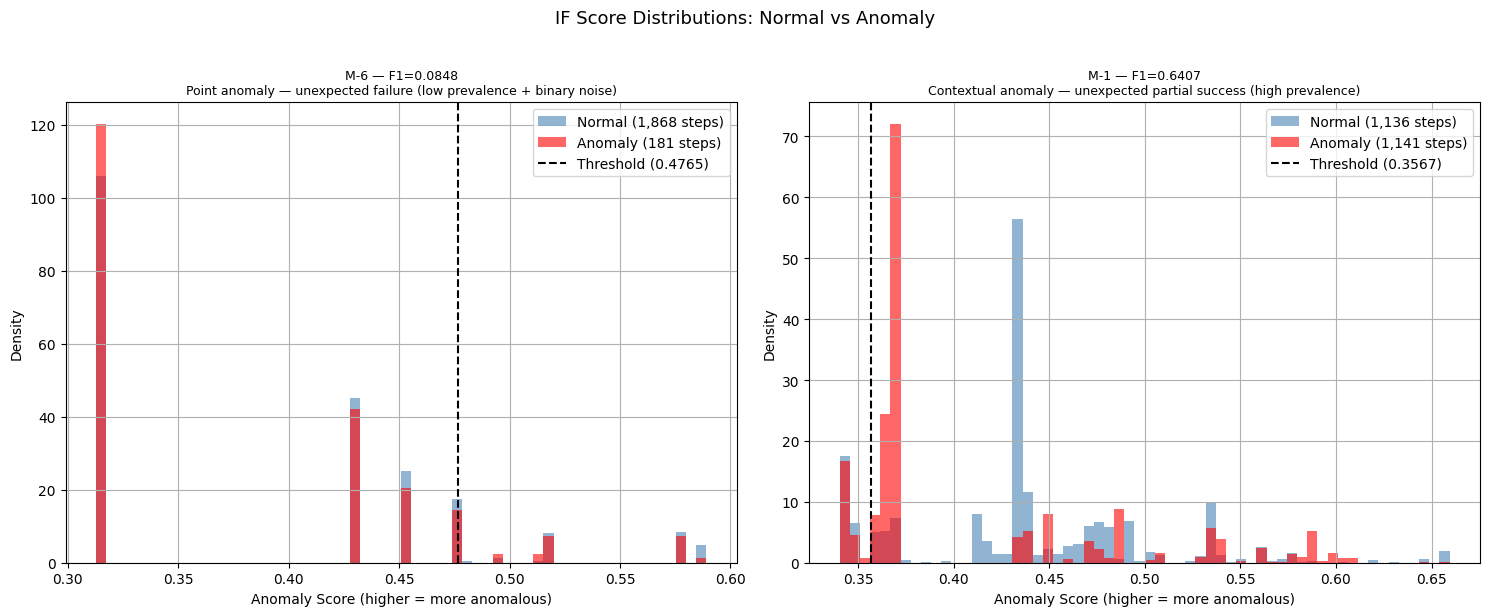

In [8]:
# Score distributions: M-6 (point, failed) vs M-1 (contextual, partial success)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, chan_id, title_suffix in zip(
    axes,
    ['M-6', 'M-1'],
    ['Point anomaly — unexpected failure (low prevalence + binary noise)',
     'Contextual anomaly — unexpected partial success (high prevalence)']
):
    r      = next(r for r in results if r['chan_id'] == chan_id)
    y_true = channels[chan_id]['y_true']
    scores = r['scores']
    thresh = r['threshold']

    normal_scores = scores[y_true == 0]
    anom_scores   = scores[y_true == 1]

    ax.hist(normal_scores, bins=60, alpha=0.6, color='steelblue', label=f'Normal ({len(normal_scores):,} steps)', density=True)
    ax.hist(anom_scores,   bins=60, alpha=0.6, color='red',       label=f'Anomaly ({len(anom_scores):,} steps)', density=True)
    ax.axvline(thresh, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({thresh:.4f})')
    ax.set_xlabel('Anomaly Score (higher = more anomalous)')
    ax.set_ylabel('Density')
    ax.set_title(f'{chan_id} — F1={r["f1"]:.4f}\n{title_suffix}', fontsize=9)
    ax.grid(True)
    ax.legend()

plt.suptitle('IF Score Distributions: Normal vs Anomaly', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

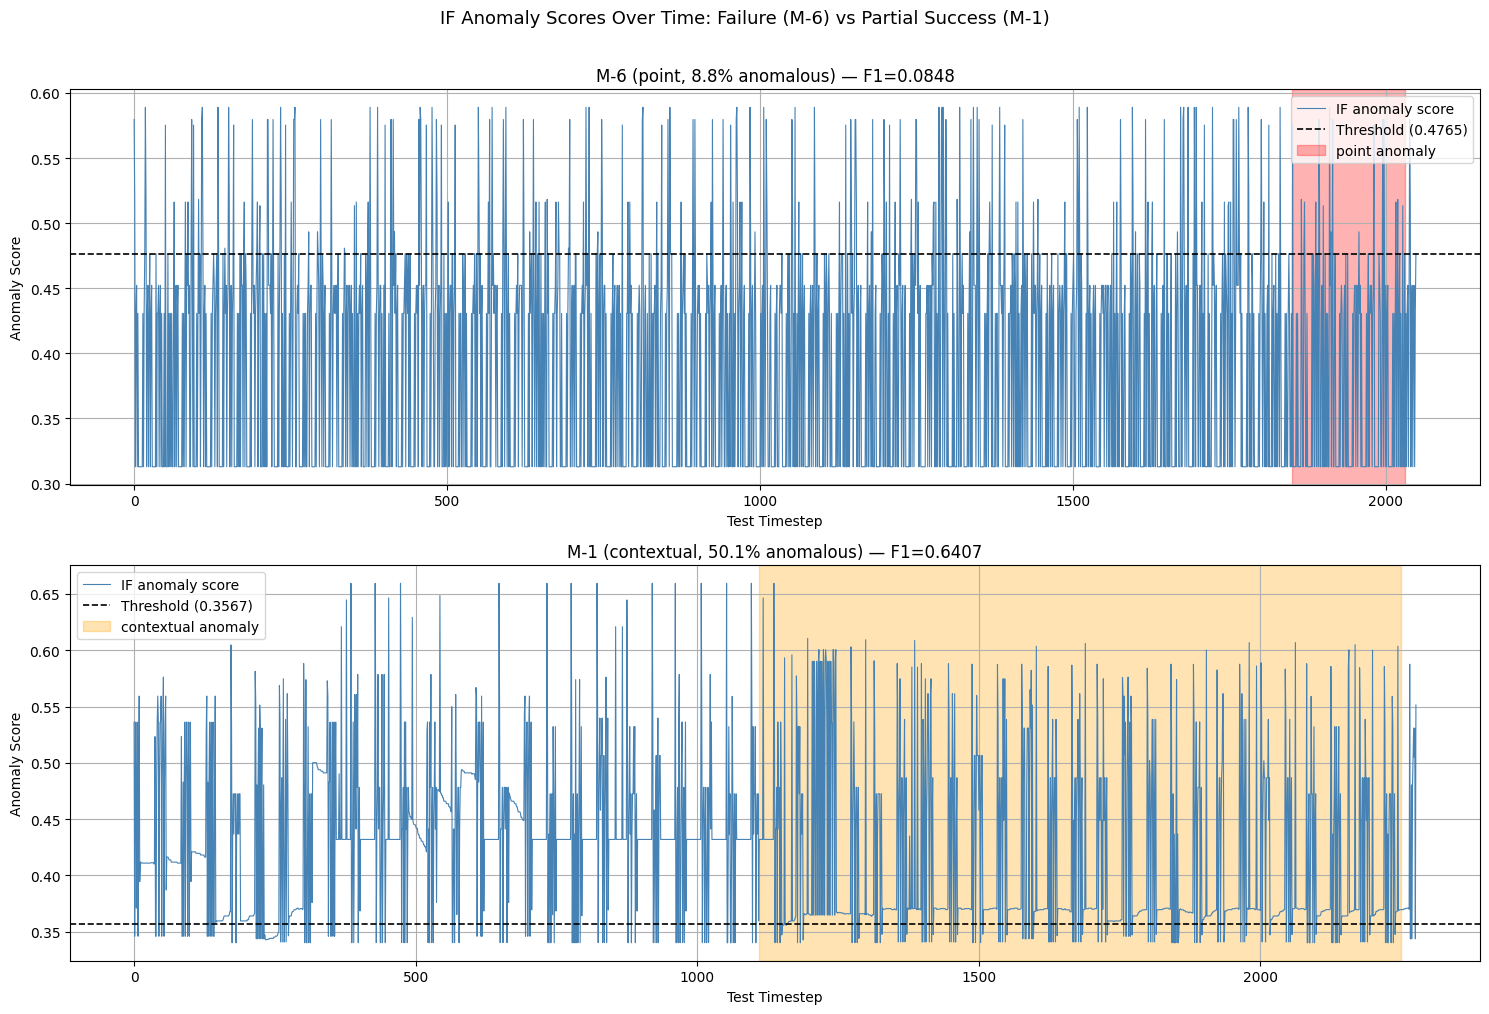

In [9]:
# Anomaly score time-series: M-6 vs M-1
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

color_map = {'point': 'red', 'contextual': 'orange'}

for ax, chan_id in zip(axes, ['M-6', 'M-1']):
    r      = next(r for r in results if r['chan_id'] == chan_id)
    data   = channels[chan_id]
    scores = r['scores']
    thresh = r['threshold']

    ax.plot(scores, color='steelblue', linewidth=0.8, label='IF anomaly score')
    ax.axhline(thresh, color='black', linestyle='--', linewidth=1.2, label=f'Threshold ({thresh:.4f})')

    legend_labels = set()
    for (start, end), atype in zip(data['sequences'], data['class_list']):
        color = color_map.get(atype, 'purple')
        label = f'{atype} anomaly' if atype not in legend_labels else ''
        legend_labels.add(atype)
        ax.axvspan(start, end, color=color, alpha=0.3, label=label)

    anom_pct = data['anomaly_pct']
    ax.set_title(f'{chan_id} ({data["anomaly_type"]}, {anom_pct:.1f}% anomalous) — F1={r["f1"]:.4f}')
    ax.set_xlabel('Test Timestep')
    ax.set_ylabel('Anomaly Score')
    ax.grid(True)
    ax.legend()

plt.suptitle('IF Anomaly Scores Over Time: Failure (M-6) vs Partial Success (M-1)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

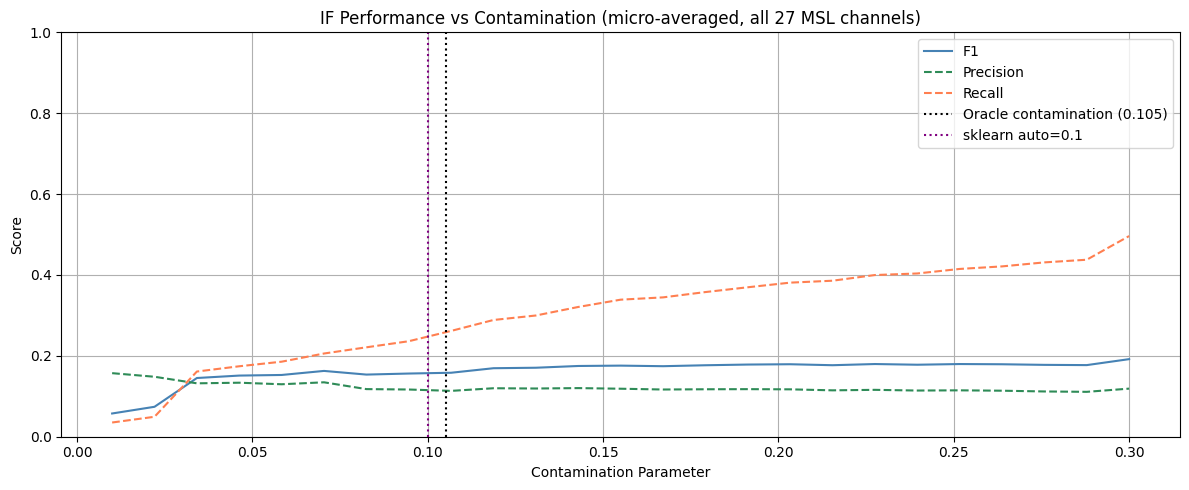

Best contamination: 0.300  F1=0.1919
At oracle (0.105):  F1=0.1582
At auto (0.1):       F1=0.1562


In [10]:
# Contamination sensitivity sweep
# Use n_estimators=100 for speed; sweep across 25 contamination values
contamination_values = np.linspace(0.01, 0.30, 25)
sweep_results = []

for c in contamination_values:
    all_true_s, all_pred_s = [], []
    for chan_id, data in channels.items():
        clf = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_STATE)
        clf.fit(data['train'])
        pred = (clf.predict(data['test']) == -1).astype(int)
        all_true_s.extend(data['y_true'])
        all_pred_s.extend(pred)
    sweep_results.append({
        'contamination': c,
        'f1':        f1_score(all_true_s, all_pred_s, zero_division=0),
        'precision': precision_score(all_true_s, all_pred_s, zero_division=0),
        'recall':    recall_score(all_true_s, all_pred_s, zero_division=0),
    })

sweep_df = pd.DataFrame(sweep_results)

# True mean anomaly rate across all MSL test timesteps
true_anomaly_rate = all_true.mean()
auto_contamination = 0.1  # sklearn default

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sweep_df['contamination'], sweep_df['f1'],        label='F1',        color='steelblue')
ax.plot(sweep_df['contamination'], sweep_df['precision'], label='Precision',  color='seagreen', linestyle='--')
ax.plot(sweep_df['contamination'], sweep_df['recall'],    label='Recall',     color='coral',    linestyle='--')
ax.axvline(true_anomaly_rate,   color='black',  linestyle=':', linewidth=1.5, label=f'Oracle contamination ({true_anomaly_rate:.3f})')
ax.axvline(auto_contamination,  color='purple', linestyle=':', linewidth=1.5, label=f'sklearn auto=0.1')
ax.set_xlabel('Contamination Parameter')
ax.set_ylabel('Score')
ax.set_title('IF Performance vs Contamination (micro-averaged, all 27 MSL channels)')
ax.set_ylim(0, 1)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

best = sweep_df.loc[sweep_df['f1'].idxmax()]
print(f'Best contamination: {best["contamination"]:.3f}  F1={best["f1"]:.4f}')
print(f'At oracle ({true_anomaly_rate:.3f}):  F1={sweep_df.iloc[(sweep_df["contamination"]-true_anomaly_rate).abs().argsort()[:1]]["f1"].values[0]:.4f}')
print(f'At auto (0.1):       F1={sweep_df.iloc[(sweep_df["contamination"]-0.1).abs().argsort()[:1]]["f1"].values[0]:.4f}')

## Hyperparameter Tuning

Two hyperparameters are worth sweeping given the MSL feature structure:

**`max_features`** — fraction of features sampled per tree (default `1.0` = all 55). With 54 binary features, reducing this forces each tree to work with a random subset. In trees where feature 0 is the *only* continuous feature, its signal dominates the splits. Lower values amplify feature 0 at the cost of losing some binary-context signal.

**`max_samples`** — number of training points per tree (default `min(256, n_train)`). Many MSL channels have 1,000–2,200 training points. At 256 samples per tree, each tree sees only ~10–25% of the normal distribution — a poorly characterized normal boundary. Increasing this should tighten the isolation of genuine outliers.

The sweep below runs a 6×4 grid over these two parameters and reports micro-averaged F1 across all 27 channels. `n_estimators=50` is used for speed; the relative ranking of configurations is stable across estimator counts.

/Users/eugenep/git/ts-anomaly-detection-foundations/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (439). max_samples will be set to n_samples for estimation.
  warn(
/Users/eugenep/git/ts-anomaly-detection-foundations/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (1024) is greater than the total number of samples (926). max_samples will be set to n_samples for estimation.
  warn(
/Users/eugenep/git/ts-anomaly-detection-foundations/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (1024) is greater than the total number of samples (764). max_samples will be set to n_samples for estimation.
  warn(
/Users/eugenep/git/ts-anomaly-detection-foundations/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (1024) is greater than the total number of samples (439). max_sa

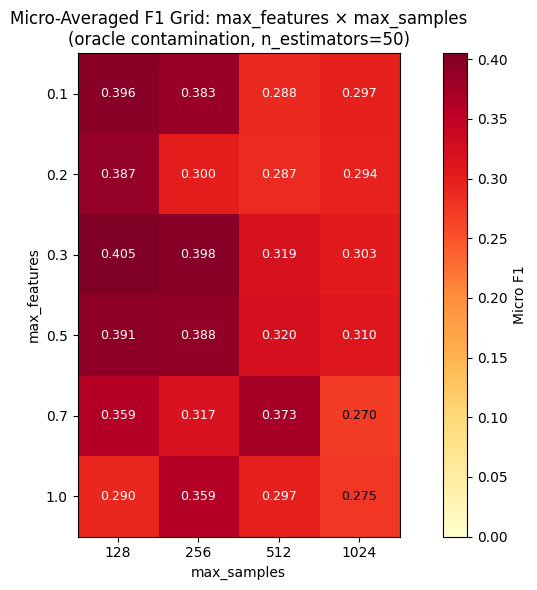

Baseline  (max_features=1.0, max_samples=256): F1=0.3594
Best config: max_features=0.3, max_samples=128  →  F1=0.4049
Improvement: +0.0456


In [11]:
max_features_grid = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
max_samples_grid  = [128, 256, 512, 1024]

grid_f1 = np.zeros((len(max_features_grid), len(max_samples_grid)))

for i, mf in enumerate(max_features_grid):
    for j, ms in enumerate(max_samples_grid):
        all_true_g, all_pred_g = [], []
        for chan_id, data in channels.items():
            contamination = max(0.001, min(0.499, data['anomaly_pct'] / 100))
            clf = IsolationForest(
                n_estimators=50,
                max_features=mf,
                max_samples=ms,
                contamination=contamination,
                random_state=RANDOM_STATE
            )
            clf.fit(data['train'])
            pred = (clf.predict(data['test']) == -1).astype(int)
            all_true_g.extend(data['y_true'])
            all_pred_g.extend(pred)
        grid_f1[i, j] = f1_score(all_true_g, all_pred_g, zero_division=0)

# Heatmap
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(grid_f1, cmap='YlOrRd', vmin=0, vmax=grid_f1.max())

ax.set_xticks(range(len(max_samples_grid)))
ax.set_xticklabels(max_samples_grid)
ax.set_yticks(range(len(max_features_grid)))
ax.set_yticklabels(max_features_grid)
ax.set_xlabel('max_samples')
ax.set_ylabel('max_features')
ax.set_title('Micro-Averaged F1 Grid: max_features × max_samples\n(oracle contamination, n_estimators=50)')

for i in range(len(max_features_grid)):
    for j in range(len(max_samples_grid)):
        ax.text(j, i, f'{grid_f1[i, j]:.3f}', ha='center', va='center', fontsize=9,
                color='white' if grid_f1[i, j] > grid_f1.max() * 0.7 else 'black')

plt.colorbar(im, ax=ax, label='Micro F1')
plt.tight_layout()
plt.show()

# Best configuration
best_i, best_j = np.unravel_index(grid_f1.argmax(), grid_f1.shape)
print(f'Baseline  (max_features=1.0, max_samples=256): F1={grid_f1[max_features_grid.index(1.0), max_samples_grid.index(256)]:.4f}')
print(f'Best config: max_features={max_features_grid[best_i]}, max_samples={max_samples_grid[best_j]}  →  F1={grid_f1[best_i, best_j]:.4f}')
print(f'Improvement: +{grid_f1[best_i, best_j] - grid_f1[max_features_grid.index(1.0), max_samples_grid.index(256)]:.4f}')

## Summary & Benchmark Position

### Isolation Forest Results (oracle contamination, n_estimators=200)

| Model | Features | Temporal | Micro F1 | Point Mean F1 | Contextual Mean F1 |
|-------|----------|----------|----------|---------------|--------------------|
| **Isolation Forest** | all 55 | No | **0.3668** | **0.1309** | **0.2580** |
| Vanilla AE | all 55 | No | TBD | TBD | TBD |
| LSTM-AE | all 55 | Yes | TBD | TBD | TBD |

### Revised Understanding

The hypothesis that IF would succeed on point anomalies and fail on contextual was **wrong**. The dominant factor is **anomaly prevalence**:

- High-prevalence channels (M-1, M-2 at 50%) score well regardless of anomaly type — the threshold problem is simply easier
- Low-prevalence point channels (M-6 at 8.8%, S-2 at 0.6%) fail — binary feature noise consumes the contamination budget before the true signal gets flagged
- Contextual channels with moderate prevalence (D-16 at 30%, F-8 at 22%) land in the middle

**IF does not cleanly separate point from contextual anomalies** on this dataset. The 54 binary telecommand features create a noisy 55-D space where anomaly prevalence matters more than anomaly character.

### What Hyperparameter Tuning Can Fix

Reducing `max_features` and increasing `max_samples` may modestly improve low-prevalence channels by amplifying the feature 0 signal and better characterizing the normal boundary. The expected gain is small — the core issue is structural, not hyperparameter-driven.

### What This Sets Up

The micro F1 of **0.3668** with oracle contamination is the non-temporal multivariate floor. If Vanilla AE improves on this, it means *learned reconstruction* is better than random partitioning for characterizing the normal distribution. If LSTM-AE then improves on Vanilla AE, it means temporal context is what finally closes the gap on the contextual/collective channels.